# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your repo is stored elsewhere in Drive.
PROJECT_ROOT = "/content/drive/MyDrive/Assignment1_2026"

Mounted at /content/drive


In [ ]:
# Install Python dependencies (run once per session)
!pip install -r {PROJECT_ROOT}/requirements.txt -q
!python -m spacy download en
!pip install ujson -q


---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [2]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/Assignment1_2026


---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [3]:
from Tools.download import download_mini

download_mini(data_dir="_data")

Step 1 / 2  —  Mini dataset (SQuAD + GloVe)
  [skip] Mini dataset already present in _data/.

Step 2 / 2  —  spaCy language model
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 148.0 MB/s eta 0:00:00
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Mini dataset download complete.


---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [5]:
!pip install ujson -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.3 MB/s eta 0:00:00


In [6]:
from Tools.preproc import preprocess

preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)

Generating train examples…


100%|██████████| 150/150 [00:05<00:00, 28.71it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:01<00:00, 25.83it/s]


  10570 questions in total
Generating word embedding…


...

100%|██████████| 30293/30293 [00:07<00:00, 3847.55it/s]


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:03<00:00, 3493.76it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/


{'train_record_file': '_data/train.npz',
 'dev_record_file': '_data/dev.npz',
 'word_emb_file': '_data/word_emb.json',
 'char_emb_file': '_data/char_emb.json',
 'train_eval_file': '_data/train_eval.json',
 'dev_eval_file': '_data/dev_eval.json',
 'word2idx_file': '_data/word2idx.json',
 'char2idx_file': '_data/char2idx.json',
 'dev_meta_file': '_data/dev_meta.json'}

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.


In [7]:
#可视化函数
import matplotlib.pyplot as plt

def plot_training_history(history, title="Training Curve"):
    steps      = [h["step"]       for h in history]
    train_loss = [h["train_loss"] for h in history]
    dev_loss   = [h["dev_loss"]   for h in history]
    dev_f1     = [h["dev_f1"]     for h in history]
    dev_em     = [h["dev_em"]     for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13)

    ax1.plot(steps, train_loss, label="Train Loss", marker="o", markersize=4)
    ax1.plot(steps, dev_loss,   label="Dev Loss",   marker="s", markersize=4)
    ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
    ax1.set_title("Loss vs. Step"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(steps, dev_f1, label="Dev F1", marker="o", markersize=4)
    ax2.plot(steps, dev_em, label="Dev EM", marker="s", markersize=4)
    ax2.set_xlabel("Step"); ax2.set_ylabel("Score")
    ax2.set_title("Dev F1 / EM vs. Step"); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Experiment 1 — Effect of Optimizer: SGD vs SGD with Momentum

**Research Question:** Does adding momentum to SGD improve QANet's convergence speed and final performance on SQuAD?

**Hypothesis:** SGD with momentum should converge faster and achieve better performance than vanilla SGD because momentum accumulates gradient history, accelerating updates in consistent directions and dampening oscillations.

**Setup:** All hyperparameters are fixed. Only `optimizer_name` changes between runs.

| Setting | Value |
|---------|-------|
| scheduler | cosine |
| learning_rate | 0.01 |
| weight_decay | 3e-7 |
| dropout | 0.1 |
| num_steps | 60000 |
| seed | 42 |

- **Exp 1a:** `optimizer_name = "sgd"` (no momentum)
- **Exp 1b:** `optimizer_name = "sgd_momentum"`, `momentum = 0.9`
**Evaluation metrics:** Best F1, Best EM, training loss, convergence speed (steps to early stop).

In [8]:
#SGD without Momentum
from TrainTools.train import train

results_exp1a = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model_exp1a",
    log_dir         = "_log_exp1a",

    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    optimizer_name = "sgd",
    scheduler_name = "cosine",
    loss_name      = "qa_nll",

    learning_rate = 0.01,
    momentum      = 0.9,
    weight_decay  = 3e-7,

    dropout       = 0.1,
    dropout_char  = 0.05,

    early_stop    = 15,
)

print(f"[Exp 1a - SGD]  Best F1: {results_exp1a['best_f1']:.4f}  |  Best EM: {results_exp1a['best_em']:.4f}")

100%|██████████| 200/200 [00:45<00:00,  4.39it/s]


STEP      200  loss 546.392102



100%|██████████| 150/150 [00:09<00:00, 16.40it/s]


VALID(train) loss 14.089065  F1 6.890788  EM 0.083333



100%|██████████| 150/150 [00:09<00:00, 16.52it/s]


...

STEP     9600  loss 13.926081



100%|██████████| 150/150 [00:09<00:00, 16.43it/s]


VALID(train) loss 4.796165  F1 6.988765  EM 0.750000



100%|██████████| 150/150 [00:09<00:00, 16.54it/s]


TEST        loss 4.864656  F1 6.343988  EM 0.500000

Learning rate: [0.009381533400219317]
Early stopping triggered.
Training finished.  Best F1: 6.8875  Best EM: 1.7500
[Exp 1a - SGD]  Best F1: 6.8875  |  Best EM: 1.7500


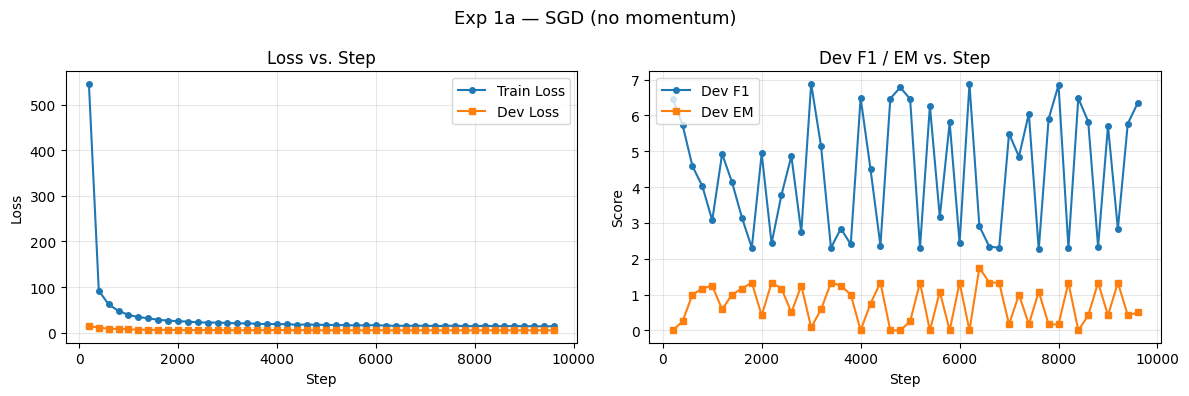

In [13]:
plot_training_history(results_exp1a["history"], title="Exp 1a — SGD (no momentum)")

In [ ]:
# SGD + Momentum (收敛太慢)
from TrainTools.train import train

results_exp1b = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model_exp1b",
    log_dir         = "_log_exp1b",

    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    optimizer_name = "sgd_momentum",
    scheduler_name = "cosine",
    loss_name      = "qa_nll",

    learning_rate = 0.01,
    momentum      = 0.9,
    weight_decay  = 3e-7,

    dropout       = 0.1,
    dropout_char  = 0.05,

    early_stop    = 15,
)

print(f"[Exp 1b - SGD+Momentum]  Best F1: {results_exp1b['best_f1']:.4f}  |  Best EM: {results_exp1b['best_em']:.4f}")

In [ ]:
plot_training_history(results_exp1b["history"], title="Exp 1b — SGD + Momentum")

---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [ ]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model_exp1b",
    log_dir       = "_log_exp1b",
    ckpt_name     = "model.pt",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")